# Neural Network Training with Scikit-Learn
In this notebook, we place all One-Hot Encoding, scaling, and the Neural Network within a single `Pipeline` and train it on the training data.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [24]:
# 1. Load cleaned data
X_train = pd.read_csv('../data/train_clean.csv')
X_val = pd.read_csv('../data/val_clean.csv')
X_test = pd.read_csv('../data/test_clean.csv')

y_train = X_train.pop('price')
y_val = X_val.pop('price')
y_test = X_test.pop('price')

print(f"Train size: {X_train.shape}")

Train size: (1726, 12)


In [25]:
# 2. Create Target Scaler
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled = target_scaler.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

In [26]:
# 3. Build Pipeline (Preprocessing + Model)
categorical_features = ['gearbox_type', 'gearbox_health', 'motor_status', 'body_status', 'chassis_status', 'brand']
numeric_features = ['year', 'mileage', 'car_age', 'yearly_mileage', 'has_insurance']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', mlp)
])

In [27]:
# 4. Train full Pipeline
print("Training neural network...")
pipeline.fit(X_train, y_train_scaled)
print("Training completed.")

Training neural network...
Iteration 1, loss = 0.84069874
Validation score: -0.285228
Iteration 2, loss = 0.46233597
Validation score: 0.186535
Iteration 3, loss = 0.38766420
Validation score: 0.303422
Iteration 4, loss = 0.32392947
Validation score: 0.418034
Iteration 5, loss = 0.26833185
Validation score: 0.473379
Iteration 6, loss = 0.23342658
Validation score: 0.537295
Iteration 7, loss = 0.20812850
Validation score: 0.572103
Iteration 8, loss = 0.19267323
Validation score: 0.589009
Iteration 9, loss = 0.18253832
Validation score: 0.609912
Iteration 10, loss = 0.17423112
Validation score: 0.629138
Iteration 11, loss = 0.16745007
Validation score: 0.640805
Iteration 12, loss = 0.16245047
Validation score: 0.650985
Iteration 13, loss = 0.15785160
Validation score: 0.658172
Iteration 14, loss = 0.15370705
Validation score: 0.665147
Iteration 15, loss = 0.15010836
Validation score: 0.672575
Iteration 16, loss = 0.14715644
Validation score: 0.680198
Iteration 17, loss = 0.14502955
Valid

In [28]:
# 5. Evaluate model
train_preds = pipeline.predict(X_train)
val_preds = pipeline.predict(X_val)
test_preds = pipeline.predict(X_test)

print(f"R2 Score - Train: {r2_score(y_train_scaled, train_preds):.4f}")
print(f"R2 Score - Val: {r2_score(y_val_scaled, val_preds):.4f}")
print(f"R2 Score - Test: {r2_score(y_test_scaled, test_preds):.4f}")

R2 Score - Train: 0.7909
R2 Score - Val: 0.7397
R2 Score - Test: 0.7953


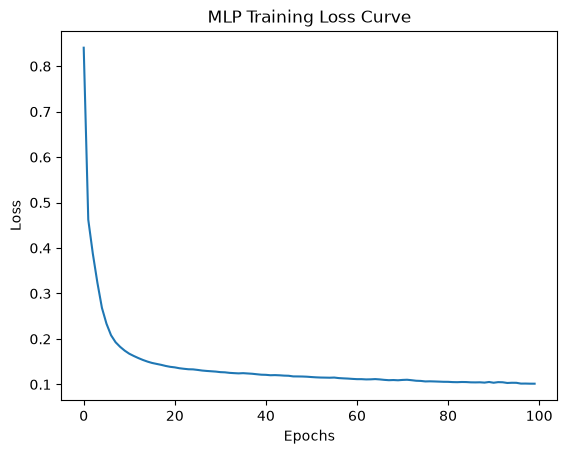

In [29]:
# Plot model loss curve
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [30]:
# 6. Save model and scaler
os.makedirs('saved_models', exist_ok=True)
joblib.dump(pipeline, 'saved_models/mlp_pipeline.pkl')
joblib.dump(target_scaler, 'saved_models/target_scaler.pkl')
print("Pipeline and Target Scaler saved successfully!")

Pipeline and Target Scaler saved successfully!
